In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import xgboost as xgb

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", __import__('sklearn').__version__)
print("xgboost:", xgb.__version__)

pandas: 3.0.3
numpy: 2.4.6
scikit-learn: 1.9.0
xgboost: 3.3.0


In [2]:
# Load the intermediate artifact produced by 02_feature_engineering.ipynb.
# This avoids re-running the bureau aggregation (1.7M rows) at every modeling iteration.

train_bureau = pd.read_csv('../data/processed/train_bureau.csv')
print(train_bureau.shape)
train_bureau.head()

(307511, 156)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,BUREAU_CREDIT_TYPE_NUNIQUE,BUREAU_DAYS_CREDIT_UPDATE_MEAN,BUREAU_DAYS_CREDIT_UPDATE_MAX,BUREAU_AMT_ANNUITY_SUM,BUREAU_AMT_ANNUITY_MEAN,BUREAU_CREDIT_ACTIVE_ACTIVE_COUNT,BUREAU_CREDIT_ACTIVE_BAD_DEBT_COUNT,BUREAU_CREDIT_ACTIVE_CLOSED_COUNT,BUREAU_CREDIT_ACTIVE_SOLD_COUNT,BUREAU_CREDIT_TYPE_MODE_COUNT
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,2.0,-499.875,-7.0,0.0,0.0,2.0,0.0,6.0,0.0,4.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,2.0,-816.000,-43.0,0.0,NaN,1.0,0.0,3.0,0.0,2.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,1.0,-532.000,-382.0,0.0,NaN,0.0,0.0,2.0,0.0,2.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,1.0,-783.000,-783.0,0.0,NaN,0.0,0.0,1.0,0.0,1.0


In [3]:
# Sanity checks before modeling: shape, TARGET distribution, and confirmation
# that the DAYS_EMPLOYED treatment and bureau merge persisted correctly.

print("Shape:", train_bureau.shape)
print("\nTARGET distribution:")
print(train_bureau['TARGET'].value_counts(normalize=True))
print("\nDAYS_EMPLOYED_ANOM check:", train_bureau['DAYS_EMPLOYED_ANOM'].value_counts().to_dict())
print("\nClients without bureau history (BUREAU_CREDIT_COUNT null):", train_bureau['BUREAU_CREDIT_COUNT'].isnull().sum())

Shape: (307511, 156)

TARGET distribution:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

DAYS_EMPLOYED_ANOM check: {0: 252137, 1: 55374}

Clients without bureau history (BUREAU_CREDIT_COUNT null): 44020


In [4]:
# Inspect column types before deciding any treatment for the baseline model.
# No assumptions from prior sessions, this is a fresh check on train_bureau.

print("Total de colunas:", train_bureau.shape[1])
print()
print("Contagem por dtype:")
print(train_bureau.dtypes.value_counts())
print()
print("Colunas não numéricas (candidatas a encoding):")
non_numeric_cols = train_bureau.select_dtypes(exclude=[np.number]).columns.tolist()
print(non_numeric_cols)

Total de colunas: 156

Contagem por dtype:
float64    99
int64      41
str        16
Name: count, dtype: int64

Colunas não numéricas (candidatas a encoding):
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


In [5]:
# Check cardinality and missing values for each categorical column
# before deciding an encoding strategy.

cat_summary = pd.DataFrame({
    'n_unique': train_bureau[non_numeric_cols].nunique(),
    'n_missing': train_bureau[non_numeric_cols].isnull().sum(),
    'pct_missing': (train_bureau[non_numeric_cols].isnull().sum() / len(train_bureau) * 100).round(2)
}).sort_values('n_unique', ascending=False)

print(cat_summary)

                            n_unique  n_missing  pct_missing
ORGANIZATION_TYPE                 58          0         0.00
OCCUPATION_TYPE                   18      96391        31.35
NAME_INCOME_TYPE                   8          0         0.00
NAME_TYPE_SUITE                    7       1292         0.42
WALLSMATERIAL_MODE                 7     156341        50.84
WEEKDAY_APPR_PROCESS_START         7          0         0.00
NAME_FAMILY_STATUS                 6          0         0.00
NAME_HOUSING_TYPE                  6          0         0.00
NAME_EDUCATION_TYPE                5          0         0.00
FONDKAPREMONT_MODE                 4     210295        68.39
HOUSETYPE_MODE                     3     154297        50.18
CODE_GENDER                        3          0         0.00
FLAG_OWN_CAR                       2          0         0.00
NAME_CONTRACT_TYPE                 2          0         0.00
FLAG_OWN_REALTY                    2          0         0.00
EMERGENCYSTATE_MODE     

In [6]:
# Convert categorical columns to pandas 'category' dtype, which XGBoost
# handles natively (enable_categorical=True), without manual encoding.
# NaN values are preserved as an implicit missing category.

for col in non_numeric_cols:
    train_bureau[col] = train_bureau[col].astype('category')

print(train_bureau[non_numeric_cols].dtypes)

NAME_CONTRACT_TYPE            category
CODE_GENDER                   category
FLAG_OWN_CAR                  category
FLAG_OWN_REALTY               category
NAME_TYPE_SUITE               category
NAME_INCOME_TYPE              category
NAME_EDUCATION_TYPE           category
NAME_FAMILY_STATUS            category
NAME_HOUSING_TYPE             category
OCCUPATION_TYPE               category
WEEKDAY_APPR_PROCESS_START    category
ORGANIZATION_TYPE             category
FONDKAPREMONT_MODE            category
HOUSETYPE_MODE                category
WALLSMATERIAL_MODE            category
EMERGENCYSTATE_MODE           category
dtype: object


In [7]:
# Separate features and target, excluding identifier columns.
feature_cols = [c for c in train_bureau.columns if c not in ['SK_ID_CURR', 'TARGET']]
X = train_bureau[feature_cols]
y = train_bureau['TARGET']

# Stratified split to preserve the 92/8 TARGET imbalance in both sets.
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("TARGET rate (train):", y_train.mean().round(4))
print("TARGET rate (val):", y_val.mean().round(4))

Train shape: (246008, 154)
Val shape: (61503, 154)
TARGET rate (train): 0.0807
TARGET rate (val): 0.0807


In [8]:
# Compute scale_pos_weight from the training set's class imbalance.
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", round(scale_pos_weight, 2))

scale_pos_weight: 11.39


In [9]:
from sklearn.metrics import roc_auc_score

# Baseline XGBoost model: near-default hyperparameters, native categorical
# support, scale_pos_weight to address class imbalance. No tuning yet,
# this is a reference point before any optimization.

model_baseline = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    enable_categorical=True,
    tree_method='hist',
    eval_metric='auc',
    random_state=42
)

model_baseline.fit(X_train, y_train)

y_pred_proba = model_baseline.predict_proba(X_val)[:, 1]
auc_baseline = roc_auc_score(y_val, y_pred_proba)

print("Baseline AUC (validação):", round(auc_baseline, 4))

Baseline AUC (validação): 0.7614


In [10]:
# Sanity check: top feature importances, to rule out an obvious leakage
# signal before trusting the AUC result.

importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model_baseline.feature_importances_
}).sort_values('importance', ascending=False)

print(importances.head(15).to_string(index=False))

                        feature  importance
                   EXT_SOURCE_3    0.103154
                   EXT_SOURCE_2    0.075074
            NAME_EDUCATION_TYPE    0.034555
                    CODE_GENDER    0.026104
                   EXT_SOURCE_1    0.025631
                FLAG_DOCUMENT_3    0.025544
                 YEARS_EMPLOYED    0.025007
                  DAYS_EMPLOYED    0.022658
                AMT_GOODS_PRICE    0.018190
                    OWN_CAR_AGE    0.017737
        BUREAU_DAYS_CREDIT_MEAN    0.016826
             NAME_CONTRACT_TYPE    0.015579
                    AMT_ANNUITY    0.014903
    REGION_RATING_CLIENT_W_CITY    0.014333
BUREAU_AMT_CREDIT_SUM_DEBT_MEAN    0.014300


#### Cross Validation

In [11]:
from sklearn.model_selection import StratifiedKFold

# 5-fold stratified cross-validation, reusing the same baseline hyperparameters.
# Gives a mean AUC plus variability across folds, more robust than a single split.

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]

    fold_scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()

    model_fold = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=fold_scale_pos_weight,
        enable_categorical=True,
        tree_method='hist',
        eval_metric='auc',
        random_state=42
    )
    model_fold.fit(X_tr, y_tr)

    y_pred = model_fold.predict_proba(X_va)[:, 1]
    fold_auc = roc_auc_score(y_va, y_pred)
    auc_scores.append(fold_auc)
    print(f"Fold {fold}: AUC = {fold_auc:.4f}")

print()
print("AUC médio:", round(np.mean(auc_scores), 4))
print("Desvio-padrão:", round(np.std(auc_scores), 4))

Fold 1: AUC = 0.7558
Fold 2: AUC = 0.7640
Fold 3: AUC = 0.7570
Fold 4: AUC = 0.7628
Fold 5: AUC = 0.7544

AUC médio: 0.7588
Desvio-padrão: 0.0039


In [12]:
from sklearn.model_selection import cross_val_predict

# Generate out-of-fold predictions: each client's predicted probability
# comes from a model that never saw that client during training.
# This avoids inflating the gain curve with in-sample overfitting.

model_for_oof = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    enable_categorical=True,
    tree_method='hist',
    eval_metric='auc',
    random_state=42
)

oof_proba = cross_val_predict(
    model_for_oof, X, y, cv=skf, method='predict_proba', n_jobs=-1
)[:, 1]

print("Shape das previsões out-of-fold:", oof_proba.shape)

Shape das previsões out-of-fold: (307511,)


In [13]:
# Business gain table: for different rejection thresholds (riskiest X% by
# predicted probability), show default rate and volume trade-off among approved clients.

gain_table = pd.DataFrame({'TARGET': y.values, 'risk_proba': oof_proba})
gain_table = gain_table.sort_values('risk_proba', ascending=False).reset_index(drop=True)

baseline_default_rate = gain_table['TARGET'].mean()
total_clients = len(gain_table)

results = []
for reject_pct in [0, 5, 10, 15, 20, 25, 30]:
    n_reject = int(total_clients * reject_pct / 100)
    n_approved = total_clients - n_reject
    approved = gain_table.iloc[n_reject:]
    approved_default_rate = approved['TARGET'].mean()
    results.append({
        'pct_rejeitado': reject_pct,
        'clientes_aprovados': n_approved,
        'pct_aprovado': 100 - reject_pct,
        'inadimplencia_aprovados_pct': round(approved_default_rate * 100, 2),
        'reducao_pp': round((baseline_default_rate - approved_default_rate) * 100, 2)
    })

gain_summary = pd.DataFrame(results)
print(f"Inadimplência atual (sem modelo, 100% aprovados): {baseline_default_rate*100:.2f}% ({total_clients} clientes)")
print()
print(gain_summary.to_string(index=False))

Inadimplência atual (sem modelo, 100% aprovados): 8.07% (307511 clientes)

 pct_rejeitado  clientes_aprovados  pct_aprovado  inadimplencia_aprovados_pct  reducao_pp
             0              307511           100                         8.07        0.00
             5              292136            95                         6.74        1.33
            10              276760            90                         5.97        2.10
            15              261385            85                         5.35        2.73
            20              246009            80                         4.83        3.24
            25              230634            75                         4.39        3.68
            30              215258            70                         4.03        4.04


#### SHAP (SHapley Additive exPlanations)

In [14]:
import shap

# SHAP explainer for the baseline XGBoost model (trained on X_train).
# TreeExplainer is optimized specifically for tree-based models like XGBoost.

explainer = shap.TreeExplainer(model_baseline)
shap_values = explainer(X_val)

print("Shape dos SHAP values:", shap_values.values.shape)

Shape dos SHAP values: (61503, 154)


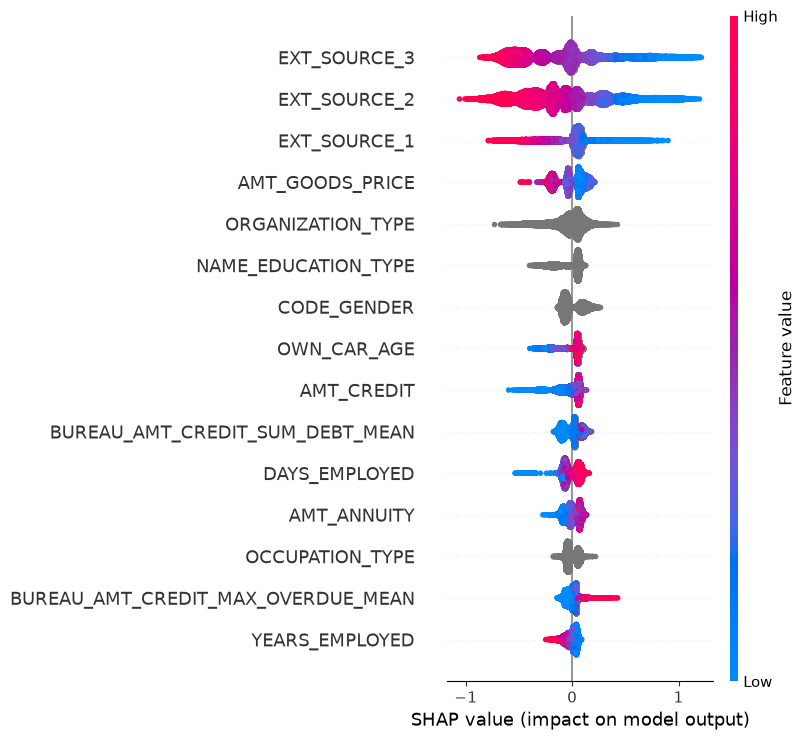

In [15]:
# Summary plot: shows both the magnitude and direction of each feature's
# impact on the prediction, across all clients in the validation set.

shap.summary_plot(shap_values, X_val, max_display=15)

#### testing a simpler model

In [16]:
# Select top 15 features using native feature importance from the model
# trained on X_train only (avoids selection bias from using validation SHAP).

top_15_features = importances.head(15)['feature'].tolist()
print("Top 15 features:", top_15_features)

X_top15 = X[top_15_features]

# Re-run the same stratified k-fold validation, now with only these 15 features.
auc_scores_top15 = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_top15, y), start=1):
    X_tr, X_va = X_top15.iloc[train_idx], X_top15.iloc[val_idx]
    y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]

    fold_scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()

    model_fold = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=fold_scale_pos_weight,
        enable_categorical=True,
        tree_method='hist',
        eval_metric='auc',
        random_state=42
    )
    model_fold.fit(X_tr, y_tr)

    y_pred = model_fold.predict_proba(X_va)[:, 1]
    fold_auc = roc_auc_score(y_va, y_pred)
    auc_scores_top15.append(fold_auc)
    print(f"Fold {fold}: AUC = {fold_auc:.4f}")

print()
print("AUC médio (15 features):", round(np.mean(auc_scores_top15), 4))
print("Desvio-padrão:", round(np.std(auc_scores_top15), 4))
print()
print("Comparação: AUC médio com 154 features:", round(np.mean(auc_scores), 4))

Top 15 features: ['EXT_SOURCE_3', 'EXT_SOURCE_2', 'NAME_EDUCATION_TYPE', 'CODE_GENDER', 'EXT_SOURCE_1', 'FLAG_DOCUMENT_3', 'YEARS_EMPLOYED', 'DAYS_EMPLOYED', 'AMT_GOODS_PRICE', 'OWN_CAR_AGE', 'BUREAU_DAYS_CREDIT_MEAN', 'NAME_CONTRACT_TYPE', 'AMT_ANNUITY', 'REGION_RATING_CLIENT_W_CITY', 'BUREAU_AMT_CREDIT_SUM_DEBT_MEAN']
Fold 1: AUC = 0.7494
Fold 2: AUC = 0.7569
Fold 3: AUC = 0.7501
Fold 4: AUC = 0.7561
Fold 5: AUC = 0.7446

AUC médio (15 features): 0.7514
Desvio-padrão: 0.0045

Comparação: AUC médio com 154 features: 0.7588


In [17]:
# Fit a single XGBoost model with the top 15 features, on the same X_train/X_val
# split used for model_baseline. The CV above already validated the AUC estimate;
# this single fit exists so we have one concrete model to feed into SHAP and the
# gain curve below, comparable to model_baseline on the exact same held-out clients.

X_train_top15 = X_train[top_15_features]
X_val_top15 = X_val[top_15_features]

model_top15 = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    enable_categorical=True,
    tree_method='hist',
    eval_metric='auc',
    random_state=42
)

model_top15.fit(X_train_top15, y_train)

y_pred_proba_top15 = model_top15.predict_proba(X_val_top15)[:, 1]
auc_top15_val = roc_auc_score(y_val, y_pred_proba_top15)

print("AUC do modelo de 15 variáveis (validação):", round(auc_top15_val, 4))
print("Comparação: AUC do baseline, 154 variáveis (validação):", round(auc_baseline, 4))

AUC do modelo de 15 variáveis (validação): 0.7519
Comparação: AUC do baseline, 154 variáveis (validação): 0.7614


In [18]:
# SHAP explainer for the simplified 15-feature model, computed on the same
# validation clients (X_val_top15) used for the baseline SHAP plot above.

explainer_top15 = shap.TreeExplainer(model_top15)
shap_values_top15 = explainer_top15(X_val_top15)

print("Shape dos SHAP values:", shap_values_top15.values.shape)

Shape dos SHAP values: (61503, 15)


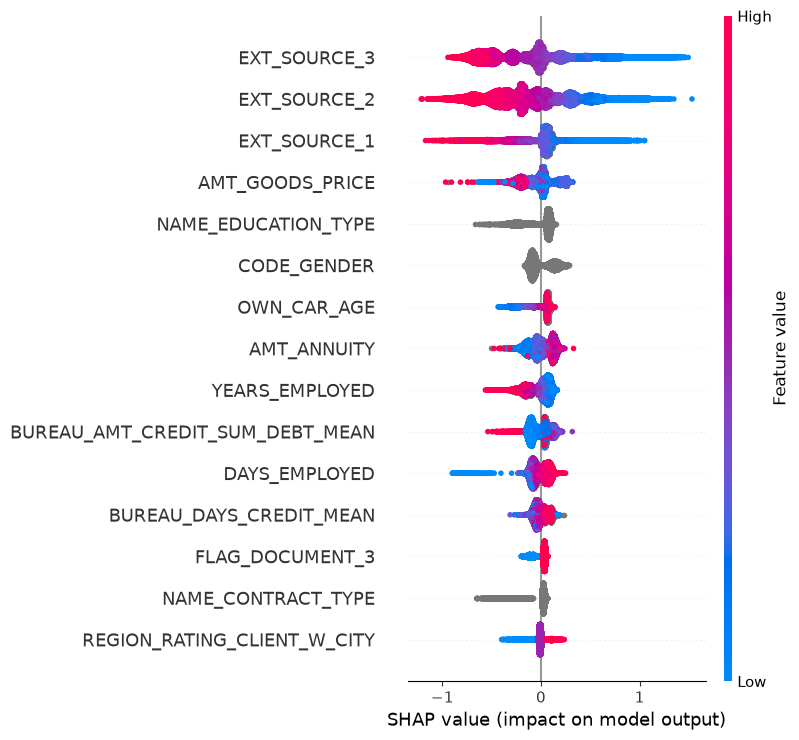

In [19]:
# Summary plot for the simplified model: same reading as the baseline plot,
# magnitude and direction of each of the 15 features across validation clients.

shap.summary_plot(shap_values_top15, X_val_top15, max_display=15)

In [20]:
# Gain table for the simplified model, built strictly on the validation set
# (X_val), not on out-of-fold predictions over the full base like the baseline
# gain_table above. Every client here is one model_top15 never trained on.
#
# Caveat: this table is on 61,503 validation clients, while the baseline
# gain_table above used out-of-fold predictions over all 307,511 clients.
# The two are not on the same base, so the "reducao_pp" columns are not
# strictly comparable side by side, each table is internally consistent,
# but they answer slightly different questions (held-out validation vs
# full-base out-of-fold).

gain_table_top15_val = pd.DataFrame({
    'TARGET': y_val.values,
    'risk_proba': y_pred_proba_top15
})
gain_table_top15_val = gain_table_top15_val.sort_values('risk_proba', ascending=False).reset_index(drop=True)

baseline_default_rate_val = gain_table_top15_val['TARGET'].mean()
total_clients_val = len(gain_table_top15_val)

results_top15_val = []
for reject_pct in [0, 5, 10, 15, 20, 25, 30]:
    n_reject = int(total_clients_val * reject_pct / 100)
    n_approved = total_clients_val - n_reject
    approved = gain_table_top15_val.iloc[n_reject:]
    approved_default_rate = approved['TARGET'].mean()
    results_top15_val.append({
        'pct_rejeitado': reject_pct,
        'clientes_aprovados': n_approved,
        'inadimplencia_aprovados_pct': round(approved_default_rate * 100, 2),
        'reducao_pp': round((baseline_default_rate_val - approved_default_rate) * 100, 2)
    })

gain_summary_top15_val = pd.DataFrame(results_top15_val)
print(f"Inadimplência atual na validação (sem modelo, 100% aprovados): {baseline_default_rate_val*100:.2f}% ({total_clients_val} clientes)")
print()
print(gain_summary_top15_val.to_string(index=False))

Inadimplência atual na validação (sem modelo, 100% aprovados): 8.07% (61503 clientes)

 pct_rejeitado  clientes_aprovados  inadimplencia_aprovados_pct  reducao_pp
             0               61503                         8.07        0.00
             5               58428                         6.72        1.35
            10               55353                         5.96        2.11
            15               52278                         5.36        2.71
            20               49203                         4.95        3.13
            25               46128                         4.51        3.56
            30               43053                         4.12        3.96


In [21]:
# Sanity check: feature importances from the 15-variable model
importances_top15 = pd.DataFrame({
    'feature': top_15_features,
    'importance': model_top15.feature_importances_
}).sort_values('importance', ascending=False)

print(importances_top15.to_string(index=False))

                        feature  importance
                   EXT_SOURCE_3    0.217868
                   EXT_SOURCE_2    0.172073
                    CODE_GENDER    0.087089
            NAME_EDUCATION_TYPE    0.085655
                FLAG_DOCUMENT_3    0.067752
                   EXT_SOURCE_1    0.061519
                 YEARS_EMPLOYED    0.050211
                  DAYS_EMPLOYED    0.044090
                    OWN_CAR_AGE    0.040873
             NAME_CONTRACT_TYPE    0.034548
    REGION_RATING_CLIENT_W_CITY    0.031209
                AMT_GOODS_PRICE    0.030710
                    AMT_ANNUITY    0.027623
BUREAU_AMT_CREDIT_SUM_DEBT_MEAN    0.025697
        BUREAU_DAYS_CREDIT_MEAN    0.023081


In [22]:
# Rebuild the top-15 list excluding DAYS_EMPLOYED, which carries the exact
# same information as YEARS_EMPLOYED (linear transform, negative days vs
# positive years). Keeping both is redundant and hard to defend to a reviewer.
# Reuses the full `importances` ranking already computed from model_baseline,
# not just the head(15) that was printed before.

top_15_features_v2 = importances[importances['feature'] != 'DAYS_EMPLOYED'].head(15)['feature'].tolist()
print("Top 15 features (sem redundância):", top_15_features_v2)

Top 15 features (sem redundância): ['EXT_SOURCE_3', 'EXT_SOURCE_2', 'NAME_EDUCATION_TYPE', 'CODE_GENDER', 'EXT_SOURCE_1', 'FLAG_DOCUMENT_3', 'YEARS_EMPLOYED', 'AMT_GOODS_PRICE', 'OWN_CAR_AGE', 'BUREAU_DAYS_CREDIT_MEAN', 'NAME_CONTRACT_TYPE', 'AMT_ANNUITY', 'REGION_RATING_CLIENT_W_CITY', 'BUREAU_AMT_CREDIT_SUM_DEBT_MEAN', 'AMT_CREDIT']


In [23]:
X_top15_v2 = X[top_15_features_v2]
auc_scores_top15_v2 = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_top15_v2, y), start=1):
    X_tr, X_va = X_top15_v2.iloc[train_idx], X_top15_v2.iloc[val_idx]
    y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]

    fold_scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()

    model_fold = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=fold_scale_pos_weight,
        enable_categorical=True,
        tree_method='hist',
        eval_metric='auc',
        random_state=42
    )
    model_fold.fit(X_tr, y_tr)

    y_pred = model_fold.predict_proba(X_va)[:, 1]
    fold_auc = roc_auc_score(y_va, y_pred)
    auc_scores_top15_v2.append(fold_auc)
    print(f"Fold {fold}: AUC = {fold_auc:.4f}")

print()
print("AUC médio (15 features, sem redundância):", round(np.mean(auc_scores_top15_v2), 4))
print("Desvio-padrão:", round(np.std(auc_scores_top15_v2), 4))
print()
print("Comparação, versão anterior (com DAYS_EMPLOYED duplicada):", 0.7514)

Fold 1: AUC = 0.7506
Fold 2: AUC = 0.7580
Fold 3: AUC = 0.7512
Fold 4: AUC = 0.7568
Fold 5: AUC = 0.7460

AUC médio (15 features, sem redundância): 0.7525
Desvio-padrão: 0.0044

Comparação, versão anterior (com DAYS_EMPLOYED duplicada): 0.7514


AUC (validação, split único): 0.7538


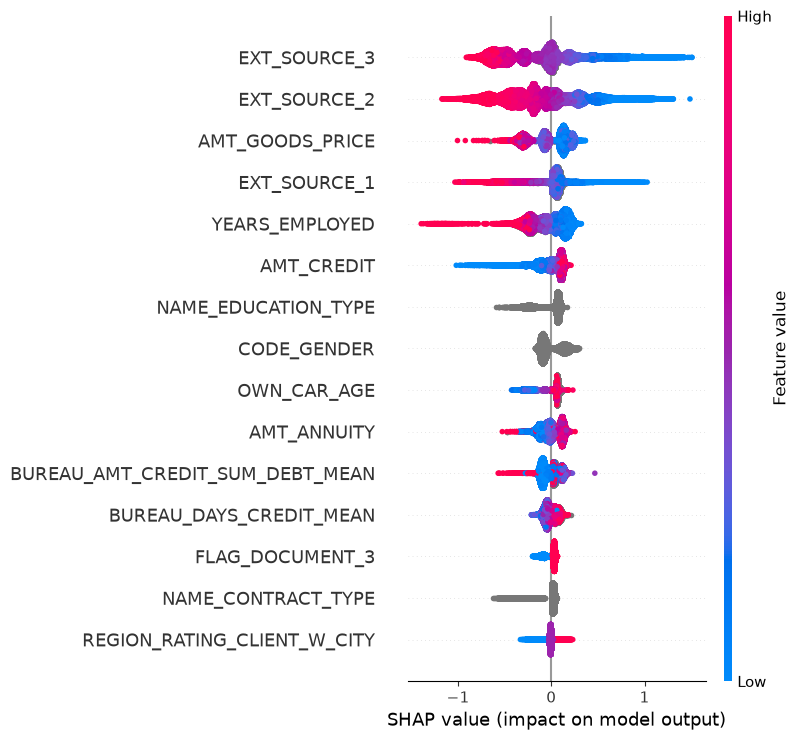

In [24]:
X_train_top15_v2 = X_train[top_15_features_v2]
X_val_top15_v2 = X_val[top_15_features_v2]

model_top15_v2 = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    enable_categorical=True,
    tree_method='hist',
    eval_metric='auc',
    random_state=42
)
model_top15_v2.fit(X_train_top15_v2, y_train)

y_pred_proba_top15_v2 = model_top15_v2.predict_proba(X_val_top15_v2)[:, 1]
auc_top15_v2 = roc_auc_score(y_val, y_pred_proba_top15_v2)
print("AUC (validação, split único):", round(auc_top15_v2, 4))

explainer_v2 = shap.TreeExplainer(model_top15_v2)
shap_values_v2 = explainer_v2(X_val_top15_v2)
shap.summary_plot(shap_values_v2, X_val_top15_v2, max_display=15)

In [25]:
# Quick correlation check among the new top 15, to catch any other hidden
# redundancy before treating this list as final.
corr_top15_v2 = X[top_15_features_v2].select_dtypes(include=[np.number]).corr()
pairs = corr_top15_v2.where(np.triu(np.ones(corr_top15_v2.shape), k=1).astype(bool)).stack()
high_corr = pairs[pairs.abs() >= 0.7].sort_values(ascending=False)
print(high_corr if len(high_corr) > 0 else "Nenhum par com |correlação| >= 0.7")

AMT_GOODS_PRICE  AMT_CREDIT     0.986968
                 AMT_ANNUITY    0.775109
AMT_ANNUITY      AMT_CREDIT     0.770138
dtype: float64


In [26]:
# Test removing AMT_GOODS_PRICE (0.987 correlation with AMT_CREDIT, the most
# redundant pair). AMT_ANNUITY is kept: correlation is moderate (0.77), and
# it represents a genuinely different concept (installment value, not
# principal), unlike the near-exact duplicate above.

top_15_features_v3 = importances[
    ~importances['feature'].isin(['DAYS_EMPLOYED', 'AMT_GOODS_PRICE'])
].head(15)['feature'].tolist()
print("Top 15 features (v3):", top_15_features_v3)

X_top15_v3 = X[top_15_features_v3]
auc_scores_top15_v3 = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_top15_v3, y), start=1):
    X_tr, X_va = X_top15_v3.iloc[train_idx], X_top15_v3.iloc[val_idx]
    y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]
    fold_scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()

    model_fold = xgb.XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        scale_pos_weight=fold_scale_pos_weight, enable_categorical=True,
        tree_method='hist', eval_metric='auc', random_state=42
    )
    model_fold.fit(X_tr, y_tr)
    y_pred = model_fold.predict_proba(X_va)[:, 1]
    fold_auc = roc_auc_score(y_va, y_pred)
    auc_scores_top15_v3.append(fold_auc)
    print(f"Fold {fold}: AUC = {fold_auc:.4f}")

print()
print("AUC médio (v3, sem AMT_GOODS_PRICE):", round(np.mean(auc_scores_top15_v3), 4))
print("Comparação, v2 (com AMT_GOODS_PRICE):", 0.7525)

Top 15 features (v3): ['EXT_SOURCE_3', 'EXT_SOURCE_2', 'NAME_EDUCATION_TYPE', 'CODE_GENDER', 'EXT_SOURCE_1', 'FLAG_DOCUMENT_3', 'YEARS_EMPLOYED', 'OWN_CAR_AGE', 'BUREAU_DAYS_CREDIT_MEAN', 'NAME_CONTRACT_TYPE', 'AMT_ANNUITY', 'REGION_RATING_CLIENT_W_CITY', 'BUREAU_AMT_CREDIT_SUM_DEBT_MEAN', 'AMT_CREDIT', 'OCCUPATION_TYPE']
Fold 1: AUC = 0.7472
Fold 2: AUC = 0.7563
Fold 3: AUC = 0.7491
Fold 4: AUC = 0.7540
Fold 5: AUC = 0.7428

AUC médio (v3, sem AMT_GOODS_PRICE): 0.7499
Comparação, v2 (com AMT_GOODS_PRICE): 0.7525


## Removing redundancy from the top-15 feature set

The original top-15 list (by native feature importance from model_baseline)
included both DAYS_EMPLOYED and YEARS_EMPLOYED, the same information in two
scales (YEARS_EMPLOYED = -DAYS_EMPLOYED / 365, a deterministic linear
transform, documented in the EDA). Keeping both is indefensible in a
portfolio context: they are not two signals, they are one signal counted
twice.

**Confirmed removal: DAYS_EMPLOYED.** Rebuilding the top-15 list excluding
DAYS_EMPLOYED (promoting the next-ranked feature, AMT_CREDIT, into the list)
not only removed the redundancy but improved mean k-fold AUC, from 0.7514
to 0.7525. This confirms DAYS_EMPLOYED added no information beyond what
YEARS_EMPLOYED already provided.

**Tested and reverted: AMT_GOODS_PRICE.** A correlation check across the
new top-15 flagged AMT_GOODS_PRICE and AMT_CREDIT at 0.99, the highest pair
in the set. Unlike the DAYS_EMPLOYED case, this is not a deterministic
transform: AMT_GOODS_PRICE is the price of the financed good, AMT_CREDIT is
the loan amount, they usually match closely but can diverge (down payments,
partial financing of the good). Removing AMT_GOODS_PRICE to test this
empirically dropped mean k-fold AUC from 0.7525 to 0.7499, confirming it
carries genuine marginal signal beyond AMT_CREDIT alone. Both variables were
kept.

**Takeaway:** high correlation between two variables is a reason to test
removal, not a reason to remove automatically. A deterministic transform
(DAYS_EMPLOYED/YEARS_EMPLOYED) is true redundancy and safe to drop; a high
but non-exact correlation (AMT_GOODS_PRICE/AMT_CREDIT) may still carry
distinct signal, and the only way to know is to measure the impact of
removing it, not just look at the correlation coefficient.

**Final top-15 set:** EXT_SOURCE_3, EXT_SOURCE_2, NAME_EDUCATION_TYPE,
CODE_GENDER, EXT_SOURCE_1, FLAG_DOCUMENT_3, YEARS_EMPLOYED, AMT_GOODS_PRICE,
OWN_CAR_AGE, BUREAU_DAYS_CREDIT_MEAN, NAME_CONTRACT_TYPE, AMT_ANNUITY,
REGION_RATING_CLIENT_W_CITY, BUREAU_AMT_CREDIT_SUM_DEBT_MEAN, AMT_CREDIT.
Mean k-fold AUC: 0.7525 (up from 0.7514 in the original, redundant list).